# Driips Opening-Session Backtest

Reproducible end-to-end run of the opening-session stop-run reversion
strategy specified in [`spec/strategy_spec.md`](../spec/strategy_spec.md):
load data â†’ run the gate-chain engines â†’ full metrics â†’ equity curve and
per-trade R distribution.

**Data mode is auto-detected.** If 1-minute CSVs are present in `data/`
(see [`data/README.md`](../data/README.md)) the run is labelled
**OWN-DATA**; otherwise deterministic synthetic sessions are generated and
the run is labelled **SYNTHETIC**. Synthetic outputs validate the code
path only â€” they support no performance claims.

In [1]:
import sys, pathlib
REPO = pathlib.Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_data_dir, make_synthetic
from src.engine import Params, backtest
from src.trend import backtest_trend
from src.metrics import metrics_table, session_returns, split_data, summarize

# ---------------- parameters ----------------
PARAMS = Params()          # defaults sized for NQ; see spec parameter table
MAX_TRADES = 3             # validated trend-continuation cap
OOS_START = None           # e.g. "2025-01-01" for a held-out year on real
                           # data; None = last 20% of sessions (synthetic)
SYNTH_DAYS = 250
SYNTH_SEED = 7

# validated two-slot categorical palette (blue = net, orange = gross)
C_NET, C_GROSS = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.spines.top": False, "axes.spines.right": False})

In [2]:
df = load_data_dir(str(REPO / "data"))
if df is not None:
    MODE = "OWN-DATA"
    mode_note = "vendor 1-minute export(s) found in data/"
else:
    MODE = "SYNTHETIC"
    mode_note = (f"no CSVs in data/ â€” generated {SYNTH_DAYS} deterministic "
                 f"sessions (seed={SYNTH_SEED}); pipeline validation only, "
                 "NOT a performance claim")
    df = make_synthetic(days=SYNTH_DAYS, seed=SYNTH_SEED)

sessions_all = df.index.normalize().unique().sort_values()
print("=" * 68)
print(f"MODE: {MODE}  ({mode_note})")
print("=" * 68)
print(f"bars: {len(df):,}   sessions: {len(sessions_all)}   "
      f"range: {sessions_all[0].date()} â†’ {sessions_all[-1].date()}")

MODE: SYNTHETIC  (no CSVs in data/ â€” generated 250 deterministic sessions (seed=7); pipeline validation only, NOT a performance claim)
bars: 97,500   sessions: 250   range: 2025-08-06 â†’ 2026-07-21


## In-sample / out-of-sample split

The development (in-sample) period is everything before `OOS_START`; the
held-out (out-of-sample) period is everything from `OOS_START` on and was
not touched during development. On real data set `OOS_START` to the start
of the held-out year. With no explicit date, the last 20% of sessions
stand in as the held-out block so the split machinery always runs.

In [3]:
if OOS_START is None:
    oos_start = sessions_all[int(len(sessions_all) * 0.8)]
else:
    oos_start = pd.Timestamp(OOS_START).tz_localize(df.index.tz)
df_is, df_oos = split_data(df, oos_start)
sess_is = df_is.index.normalize().unique().sort_values()
sess_oos = df_oos.index.normalize().unique().sort_values()
print(f"in-sample:      {sess_is[0].date()} â†’ {sess_is[-1].date()}  "
      f"({len(sess_is)} sessions)")
print(f"out-of-sample:  {sess_oos[0].date()} â†’ {sess_oos[-1].date()}  "
      f"({len(sess_oos)} sessions)")

in-sample:      2025-08-06 â†’ 2026-05-12  (200 sessions)
out-of-sample:  2026-05-13 â†’ 2026-07-21  (50 sessions)


In [4]:
runs, frames = [], {}
for label, frame, sess in [("IS", df_is, sess_is), ("OOS", df_oos, sess_oos)]:
    t_trend, _ = backtest_trend(frame, PARAMS, MAX_TRADES)
    t_base, _ = backtest(frame, PARAMS, max_trades=MAX_TRADES)
    frames[("trend", label)] = t_trend
    frames[("base", label)] = t_base
    runs.append(summarize(t_trend, sess, f"trend {label}"))
    runs.append(summarize(t_base, sess, f"base {label}"))

print(f"[{MODE}] cost assumptions: {PARAMS.commission_pts} pts commission "
      f"+ {PARAMS.slippage_pts} pts slippage per round turn, deducted in R.")
print(f"[{MODE}] gross figures are before costs, net after; the headline")
print("Sharpe is full-period and unconditional (flat sessions count as 0);")
print("the traded-days-only Sharpe is CONDITIONAL and shown second.")
metrics_table(runs)

[SYNTHETIC] cost assumptions: 0.225 pts commission + 0.5 pts slippage per round turn, deducted in R.
[SYNTHETIC] gross figures are before costs, net after; the headline
Sharpe is full-period and unconditional (flat sessions count as 0);
the traded-days-only Sharpe is CONDITIONAL and shown second.


label,trend IS,base IS,trend OOS,base OOS
sessions,200.000,200.000,50.000,50.000
trades,111.000,93.000,24.000,21.000
hit_rate_pct,45.900,48.400,54.200,57.100
total_R_gross,101.500,99.370,24.010,23.100
total_R_net,67.940,70.570,16.360,16.710
avg_R_net_per_trade,0.612,0.759,0.682,0.796
sharpe_annualized,2.590,3.060,2.590,2.840
sharpe_traded_days_only (conditional),3.950,4.710,4.120,4.530
max_drawdown_R,-13.830,-11.280,-11.520,-8.420
max_drawdown_duration_sessions,80.000,43.000,25.000,25.000


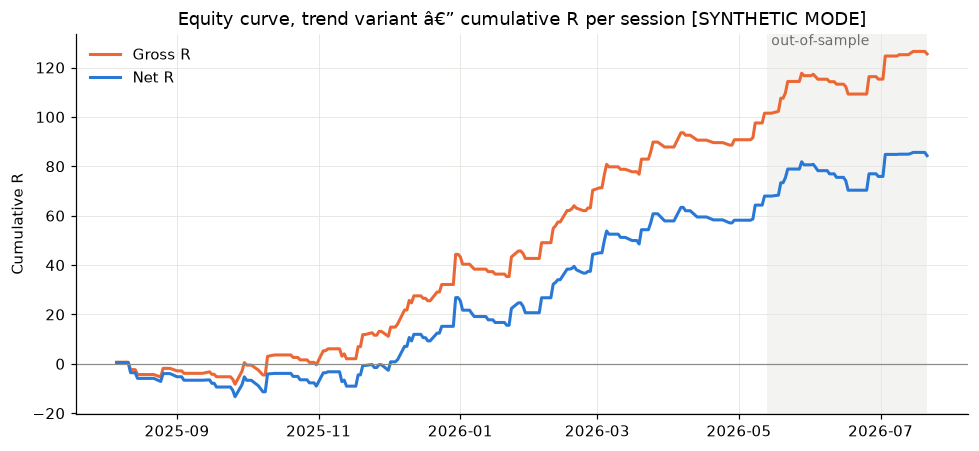

In [5]:
# Equity curve â€” trend-continuation variant (validated configuration),
# cumulative R per session over the FULL period, gross and net.
t_full = pd.concat([frames[("trend", "IS")], frames[("trend", "OOS")]],
                   ignore_index=True)
eq_net = session_returns(t_full, sessions_all, "r").cumsum()
eq_gross = session_returns(t_full, sessions_all, "r_gross").cumsum()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(eq_gross.index, eq_gross.values, color=C_GROSS, lw=2, label="Gross R")
ax.plot(eq_net.index, eq_net.values, color=C_NET, lw=2, label="Net R")
ax.axvspan(oos_start, sessions_all[-1], color="#8a8a86", alpha=0.10, lw=0)
ax.axhline(0, color="#8a8a86", lw=0.8)
ax.text(oos_start, ax.get_ylim()[1], " out-of-sample", va="top",
        color="#6b6b68", fontsize=9)
ax.set_title(f"Equity curve, trend variant â€” cumulative R per session "
             f"[{MODE} MODE]")
ax.set_ylabel("Cumulative R")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

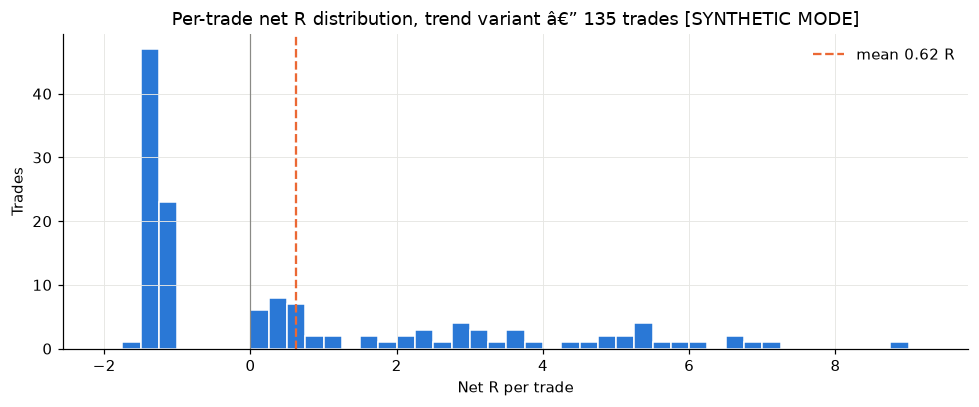

[SYNTHETIC] every figure above was produced in SYNTHETIC mode.
SYNTHETIC results are pipeline validation only â€” the generator
plants the very structure the engine hunts, so profitability or
unprofitability here says nothing about the strategy on markets.


In [6]:
# Per-trade R distribution (net, after costs) â€” trend variant, full period.
fig, ax = plt.subplots(figsize=(9, 3.8))
r = t_full["r"]
bins = np.arange(np.floor(r.min() * 2) / 2, np.ceil(r.max() * 2) / 2 + 0.5, 0.25)
ax.hist(r, bins=bins, color=C_NET, edgecolor="white", linewidth=1)
ax.axvline(0, color="#8a8a86", lw=0.8)
ax.axvline(r.mean(), color=C_GROSS, lw=1.5, ls="--",
           label=f"mean {r.mean():.2f} R")
ax.set_title(f"Per-trade net R distribution, trend variant â€” "
             f"{len(r)} trades [{MODE} MODE]")
ax.set_xlabel("Net R per trade"); ax.set_ylabel("Trades")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"[{MODE}] every figure above was produced in {MODE} mode.")
if MODE == "SYNTHETIC":
    print("SYNTHETIC results are pipeline validation only â€” the generator")
    print("plants the very structure the engine hunts, so profitability or")
    print("unprofitability here says nothing about the strategy on markets.")

## Limitations

- **Sample size.** A few trades per day at most, many flat sessions; hit
  rate and expectancy carry wide confidence intervals at these counts.
- **Single-instrument concentration.** Evidence from one index future
  only; no transfer claim to other instruments.
- **Regime dependence.** The edge is conditional on how the 09:30 auction
  has traded in the tested window; opening-liquidity regime changes can
  degrade it without warning.
- **Slippage uncertainty.** Zone-midpoint fills with a flat slippage
  allowance; real limit-order queue position and stop slippage in fast
  markets are worse than any flat assumption on some days.
- **Capacity.** The strategy trades moments of thin, one-sided depth by
  design; nothing here speaks to execution at size.